## RNN


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [103]:
X_train_pad = np.load("../data/tokenization/X_train_pad.npy")
X_val_pad = np.load("../data/tokenization/X_val_pad.npy")
X_test_pad = np.load("../data/tokenization/X_test_pad.npy")

y_train = np.load("../data/tokenization/y_train.npy")
y_val = np.load("../data/tokenization/y_val.npy")
y_test = np.load("../data/tokenization/y_test.npy")

In [104]:
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train_pad shape: (34998, 200)
X_val_pad shape: (7502, 200)
X_test_pad shape: (7500, 200)
y_train shape: (34998,)
y_val shape: (7502,)
y_test shape: (7500,)


In [105]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
RNN_UNITS =64
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS=10

In [106]:
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,mask_zero=True),
    SimpleRNN(RNN_UNITS, dropout=0.1, recurrent_dropout=0.1),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

In [107]:
rnn_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss ="binary_crossentropy",
    metrics=["accuracy"]
)

In [108]:
rnn_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_17 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [112]:
early_stopping =EarlyStopping(
    monitor ="val_loss",
    patience =7,
    restore_best_weights=True
)

In [113]:
history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 55s 50ms/step - accuracy: 0.7530 - loss: 0.5154 - val_accuracy: 0.8017 - val_loss: 0.4597
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 59s 54ms/step - accuracy: 0.8241 - loss: 0.4109 - val_accuracy: 0.8207 - val_loss: 0.4486
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 56s 51ms/step - accuracy: 0.8282 - loss: 0.3916 - val_accuracy: 0.6818 - val_loss: 0.5909
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 53s 49ms/step - accuracy: 0.8196 - loss: 0.4084 - val_accuracy: 0.8078 - val_loss: 0.4469
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 53s 48ms/step - accuracy: 0.8611 - loss: 0.3399 - val_accuracy: 0.7769 - val_loss: 0.5007
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 58s 53ms/step - accuracy: 0.8543 - loss: 0.3438 - val_accuracy: 0.7905 - val_loss: 0.5051
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 61s 56ms/step - accuracy: 0.8495 - loss: 0.3535 - val_accuracy: 0.7325 - val_loss: 0.5642
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 59s 54ms/step - accuracy: 0.8566 -

In [114]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.753014,0.515392,0.801653,0.459668
1,0.824076,0.410949,0.820714,0.448648
2,0.828190,0.391633,0.681818,0.590947
3,0.819647,0.408415,0.807785,0.446913
4,0.861078,0.339887,0.776860,0.500730
5,0.854306,0.343806,0.790456,0.505072
6,0.849534,0.353455,0.732471,0.564152
7,0.856563,0.339458,0.791922,0.517090
8,0.860335,0.332979,0.784458,0.518118
9,0.887136,0.284325,0.801653,0.533377


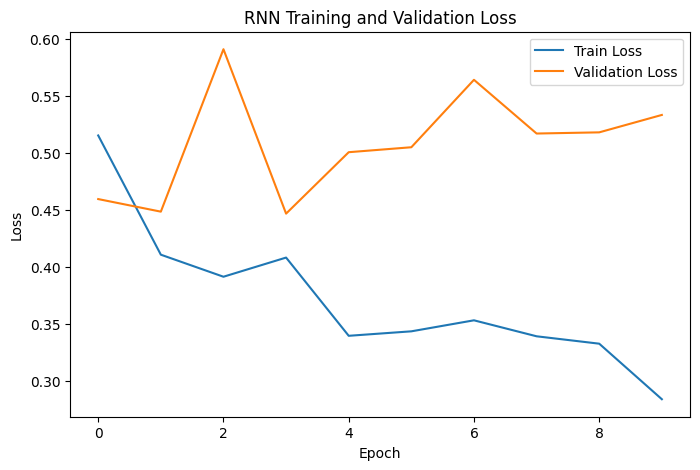

In [116]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.show()

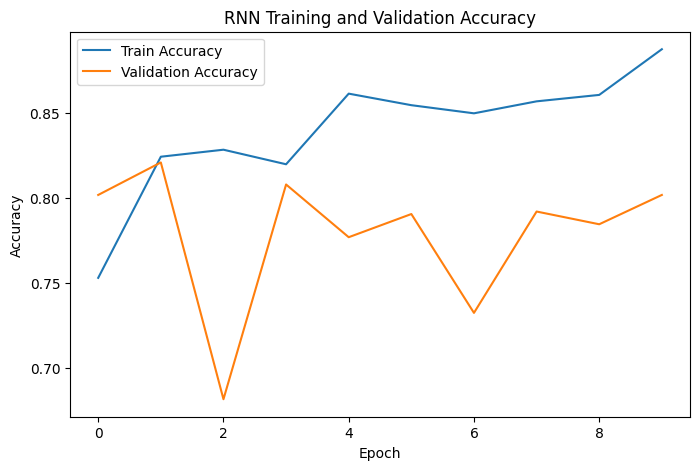

In [117]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.show()

In [118]:
val_loss, val_accuracy = rnn_model.evaluate(X_val_pad, y_val, verbose=0)

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 4))

Validation Loss: 0.4469
Validation Accuracy: 0.8078


In [119]:
y_val_prob = rnn_model.predict(X_val_pad)
y_val_pred =(y_val_prob >0.5).astype(int).flatten()

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step


In [120]:
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation Metrics")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Validation Metrics
Accuracy : 0.8078
Precision: 0.8361
Recall   : 0.7657
F1 Score : 0.7993


In [121]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82      3751
           1       0.84      0.77      0.80      3751

    accuracy                           0.81      7502
   macro avg       0.81      0.81      0.81      7502
weighted avg       0.81      0.81      0.81      7502



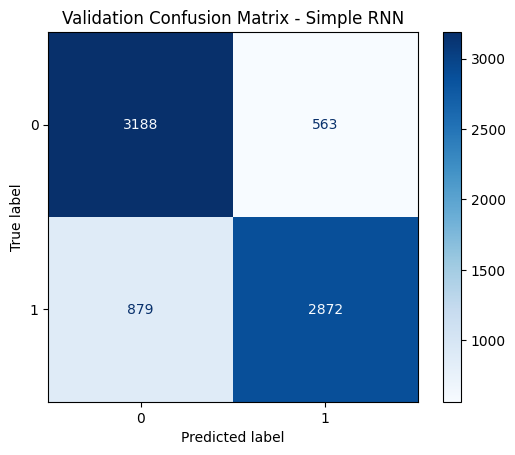

In [122]:
val_cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=val_cm)
disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix - Simple RNN")
plt.show()

In [123]:
test_loss, test_accuracy = rnn_model.evaluate(X_test_pad, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.4357
Test Accuracy: 0.8124


In [124]:
y_test_prob = rnn_model.predict(X_test_pad)
y_test_pred = (y_test_prob > 0.5).astype(int).flatten()

235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


In [125]:
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Metrics")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Metrics
Accuracy : 0.8124
Precision: 0.8377
Recall   : 0.7749
F1 Score : 0.8051


In [126]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      3750
           1       0.84      0.77      0.81      3750

    accuracy                           0.81      7500
   macro avg       0.81      0.81      0.81      7500
weighted avg       0.81      0.81      0.81      7500



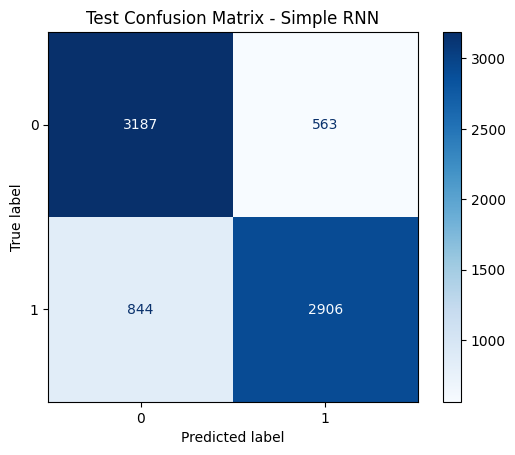

In [127]:
test_cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp.plot(cmap="Blues")
plt.title("Test Confusion Matrix - Simple RNN")
plt.show()

In [128]:
rnn_results = pd.DataFrame([
    {
        "Model": "Simple RNN",
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1
    }
])

rnn_results

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Simple RNN,0.807785,0.836099,0.765662,0.799332,0.8124,0.837705,0.774933,0.805098


In [129]:
rnn_results.to_csv("../results/rnn_results.csv", index=False)
print("RNN results saved.")

RNN results saved.


In [130]:
rnn_model.save("../results/rnn_model.keras")
print("RNN model saved.")

RNN model saved.
